In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,Flatten
from tensorflow.keras.activations import relu,softmax
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import classification_report,confusion_matrix,ConfusionMatrixDisplay

C:\Users\Shibam\AppData\Roaming\Python\Python313\site-packages\requests\__init__.py:113: RequestsDependencyWarning: urllib3 (2.6.3) or chardet (7.4.3)/charset_normalizer (3.4.4) doesn't match a supported version!
  warnings.warn(


In [2]:
(x_train,y_train),(x_test,y_test) = mnist.load_data()

In [3]:
print(x_train.shape)

(60000, 28, 28)


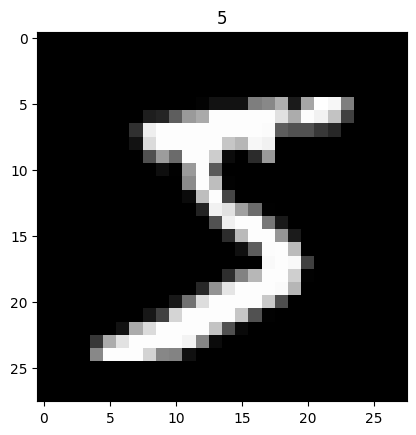

In [4]:
plt.imshow(x_train[0],cmap = 'gray')
plt.title(y_train[0])
plt.show()

In [5]:
x_train = x_train/255.0
x_test = x_test/255.0

In [6]:
model = Sequential([
    Flatten(input_shape=(28, 28)),
    Dense(128, activation='relu'),
    Dense(64, activation='relu'),
    Dense(32, activation='relu'),
    Dense(10, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    x_train,
    y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.2
)

C:\Users\Shibam\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - accuracy: 0.9184 - loss: 0.2785 - val_accuracy: 0.9620 - val_loss: 0.1279
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 23s 9ms/step - accuracy: 0.9660 - loss: 0.1127 - val_accuracy: 0.9639 - val_loss: 0.1170
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 8ms/step - accuracy: 0.9754 - loss: 0.0801 - val_accuracy: 0.9697 - val_loss: 0.1049
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 20s 7ms/step - accuracy: 0.9794 - loss: 0.0624 - val_accuracy: 0.9693 - val_loss: 0.1043
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 22s 8ms/step - accuracy: 0.9847 - loss: 0.0482 - val_accuracy: 0.9728 - val_loss: 0.0991
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 22s 9ms/step - accuracy: 0.9875 - loss: 0.0377 - val_accuracy: 0.9663 - val_loss: 0.1205
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 18s 7ms/step - accuracy: 0.9880 - loss: 0.0363 - val_accuracy: 0.9713 - val_loss: 0.1061
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 24s 10ms/step - accuracy: 0.9905 - loss: 

In [7]:
test_loss,test_accuracy = model.evaluate(x_test,y_test)
print("Test Loss:",test_loss)
print("Test Accuracy:",test_accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9772 - loss: 0.0850
Test Loss: 0.08496700972318649
Test Accuracy: 0.9771999716758728


In [8]:
predictions = model.predict(x_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


In [9]:
predicted_digits = np.argmax(predictions,axis = 1)
print("Predicted:", predicted_digits[:10])
print("Actual   :", y_test[:10])

Predicted: [7 2 1 0 4 1 4 9 5 9]
Actual   : [7 2 1 0 4 1 4 9 5 9]


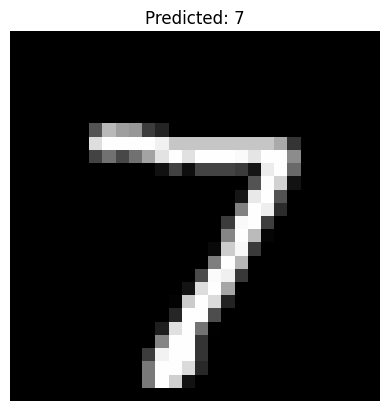

In [10]:
plt.imshow(x_test[0], cmap='gray')
plt.title(f"Predicted: {predicted_digits[0]}")
plt.axis("off")
plt.show()

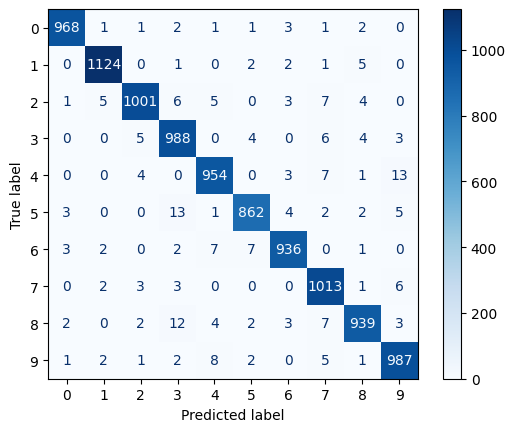

In [11]:
cm = confusion_matrix(y_test,predicted_digits)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues")
plt.show()

In [12]:
print(classification_report(y_test,predicted_digits))

              precision    recall  f1-score   support

           0       0.99      0.99      0.99       980
           1       0.99      0.99      0.99      1135
           2       0.98      0.97      0.98      1032
           3       0.96      0.98      0.97      1010
           4       0.97      0.97      0.97       982
           5       0.98      0.97      0.97       892
           6       0.98      0.98      0.98       958
           7       0.97      0.99      0.98      1028
           8       0.98      0.96      0.97       974
           9       0.97      0.98      0.97      1009

    accuracy                           0.98     10000
   macro avg       0.98      0.98      0.98     10000
weighted avg       0.98      0.98      0.98     10000



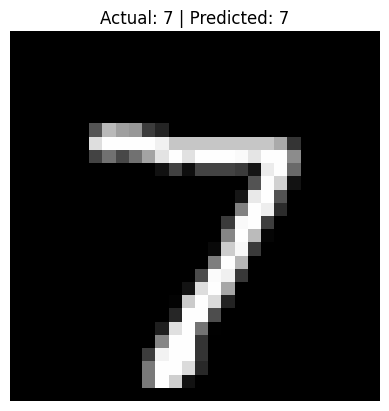

In [13]:
index = 0

plt.imshow(x_test[index], cmap='gray')
plt.title(f"Actual: {y_test[index]} | Predicted: {predicted_digits[index]}")
plt.axis('off')
plt.show()

In [14]:
wrong_predictions = np.where(predicted_digits != y_test)[0]

In [15]:
print("Total Wrong Predictions:", len(wrong_predictions))

Total Wrong Predictions: 228


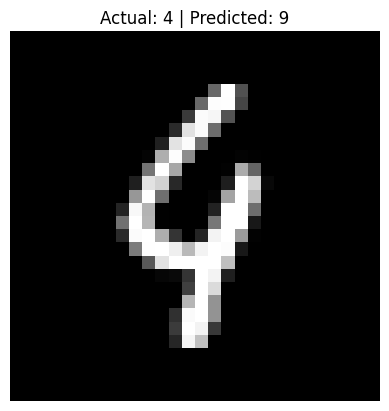

In [16]:
index = wrong_predictions[0]

plt.imshow(x_test[index], cmap='gray')
plt.title(f"Actual: {y_test[index]} | Predicted: {predicted_digits[index]}")
plt.axis('off')
plt.show()

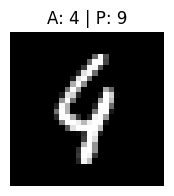

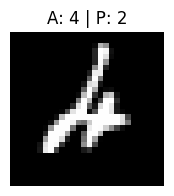

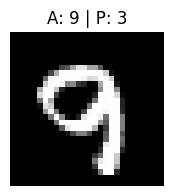

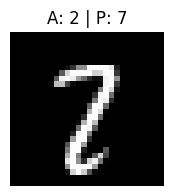

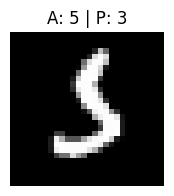

In [17]:
for i in range(5):
    index = wrong_predictions[i]

    plt.figure(figsize=(2,2))
    plt.imshow(x_test[index], cmap='gray')
    plt.title(f"A: {y_test[index]} | P: {predicted_digits[index]}")
    plt.axis('off')
    plt.show()

In [18]:
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,Flatten,Conv2D,MaxPooling2D
from tensorflow.keras.activations import relu,softmax
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import classification_report,confusion_matrix,ConfusionMatrixDisplay

In [19]:
(x_train,y_train),(x_test,y_test) = mnist.load_data()

In [20]:
x_train = x_train/255.0
x_test = x_test/255.0

In [21]:
x_train = x_train.reshape(-1,28,28,1)
x_test = x_test.reshape(-1,28,28,1)

In [22]:
#Why do we reshape?
print(x_train.shape)
'''(Number of Images,
 Height,
 Width,
 Channels)'''
'''-1 Means TensorFlow calculate the number of images automatically,It becomes 60000,28 height,28 width,1 One grayscale channel'''

(60000, 28, 28, 1)


'-1 Means TensorFlow calculate the number of images automatically,It becomes 60000,28 height,28 width,1 One grayscale channel'

In [35]:
#Why Doesn't CNN Need Flatten Immediately?
'''because Dense layers only understand vectors.

CNN layers can directly process images.

So we do not use flatten at the beginning.

We use flatten only after the convolution and pooling layers have extracted useful features.'''

model = Sequential([
    Conv2D(32,(3,3),activation='relu',input_shape = (28,28,1)),
    MaxPooling2D((2,2)),
    Conv2D(64,(3,3),activation = 'relu'),
    MaxPooling2D((2,2)),
    Flatten(),
    Dense(64,activation = 'relu'),
    Dense(10,activation = 'softmax')
])
'''Conv2D means:

"Look for patterns in an image."

Instead of memorizing every pixel, it learns things like:

Horizontal lines
Vertical lines
Curves
Corners
Small shapes

These simple patterns are later combined to recognize complete digits

The number 32 means:

The CNN creates 32 different filters.

Think of each filter as a different detective.

What does (3,3) mean?
(3,3) This is called the kernel size or filter size.
It means the filter is:
3 pixels wide × 3 pixels tall
So the filter looks at a 3×3 area at a time.

What is input_shape=(28,28,1)?
input_shape=(28,28,1) This tells TensorFlow the size of each input image.
Breaking it down:
28 → Height 28 → Width 1 → Grayscale Channel
So every image has: 28 × 28 pixels -> 1 color channel

If you were using RGB color images, the input shape would look like:
because RGB images have 3 channels: Red Green Blue'''

C:\Users\Shibam\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


'Conv2D means:\n\n"Look for patterns in an image."\n\nInstead of memorizing every pixel, it learns things like:\n\nHorizontal lines\nVertical lines\nCurves\nCorners\nSmall shapes\n\nThese simple patterns are later combined to recognize complete digits\n\nThe number 32 means:\n\nThe CNN creates 32 different filters.\n\nThink of each filter as a different detective.\n\nWhat does (3,3) mean?\n(3,3) This is called the kernel size or filter size.\nIt means the filter is:\n3 pixels wide × 3 pixels tall\nSo the filter looks at a 3×3 area at a time.\n\nWhat is input_shape=(28,28,1)?\ninput_shape=(28,28,1) This tells TensorFlow the size of each input image.\nBreaking it down:\n28 → Height 28 → Width 1 → Grayscale Channel\nSo every image has: 28 × 28 pixels -> 1 color channel\n\nIf you were using RGB color images, the input shape would look like:\nbecause RGB images have 3 channels: Red Green Blue'

In [36]:
#Pooling is convert large picture to small picture and look for every tiny pixel
'''((2,2)) means 2 rows x 2 columns
again in conv2d 64 layers because after pooling picture is small now thats why we need more
layers to detect the features'''

'((2,2)) means 2 rows x 2 columns\nagain in conv2d 64 layers because after pooling picture is small now thats why we need more\nlayers to detect the features'

In [37]:
#Flatten Layer convert picture features into Ann features as 1d vector

In [38]:
model.compile(
    optimizer = 'adam',
    loss = 'sparse_categorical_crossentropy',
    metrics = ['accuracy']
)
history = model.fit(x_train,y_train,epochs = 10,batch_size = 32,validation_split = 0.2,callbacks = EarlyStopping())

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 41s 26ms/step - accuracy: 0.9522 - loss: 0.1567 - val_accuracy: 0.9782 - val_loss: 0.0716
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 32s 20ms/step - accuracy: 0.9841 - loss: 0.0514 - val_accuracy: 0.9857 - val_loss: 0.0449
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 47s 24ms/step - accuracy: 0.9887 - loss: 0.0353 - val_accuracy: 0.9840 - val_loss: 0.0557


In [39]:
test_loss,test_accuracy = model.evaluate(x_test,y_test)
print("Test Loss:",test_loss)
print("Test Accuracy:",test_accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.9837 - loss: 0.0534
Test Loss: 0.05335843935608864
Test Accuracy: 0.9836999773979187


In [40]:
predictions1 = model.predict(x_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step


In [41]:
predicted_digits1 = np.argmax(predictions1,axis = 1)

In [42]:
print("Predictions:",predicted_digits1[:10])
print("Actual:",y_test[:10])

Predictions: [7 2 1 0 4 1 4 9 5 9]
Actual: [7 2 1 0 4 1 4 9 5 9]


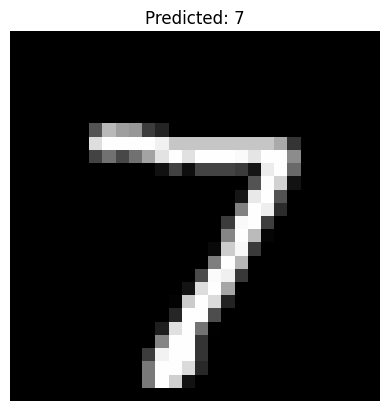

In [43]:
plt.imshow(x_test[0], cmap='gray')
plt.title(f"Predicted: {predicted_digits[0]}")
plt.axis("off")
plt.show()

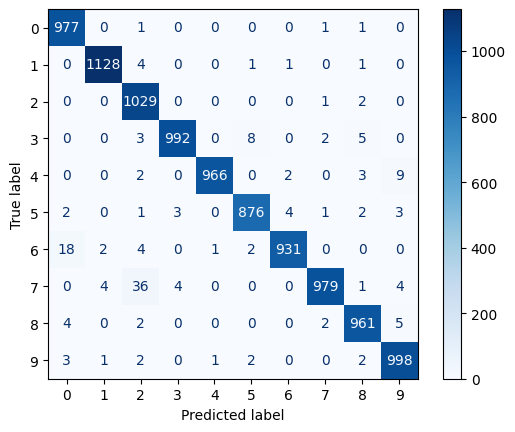

In [44]:
cm = confusion_matrix(y_test,predicted_digits1)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues")
plt.show()

In [45]:
print(classification_report(y_test,predicted_digits1))

              precision    recall  f1-score   support

           0       0.97      1.00      0.98       980
           1       0.99      0.99      0.99      1135
           2       0.95      1.00      0.97      1032
           3       0.99      0.98      0.99      1010
           4       1.00      0.98      0.99       982
           5       0.99      0.98      0.98       892
           6       0.99      0.97      0.98       958
           7       0.99      0.95      0.97      1028
           8       0.98      0.99      0.98       974
           9       0.98      0.99      0.98      1009

    accuracy                           0.98     10000
   macro avg       0.98      0.98      0.98     10000
weighted avg       0.98      0.98      0.98     10000



In [46]:
wrong_predictions1 = np.where(predicted_digits1 != y_test)[0]
print('Total Wrong Predictions are:',len(wrong_predictions1))

Total Wrong Predictions are: 163


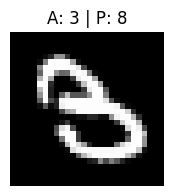

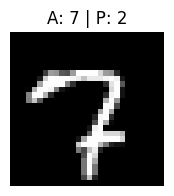

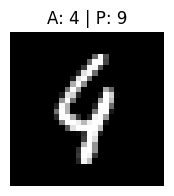

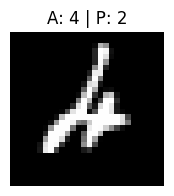

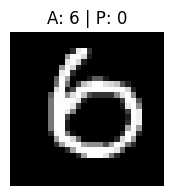

In [47]:
for i in range(5):
    index = wrong_predictions1[i]

    plt.figure(figsize=(2,2))
    plt.imshow(x_test[index], cmap='gray')
    plt.title(f"A: {y_test[index]} | P: {predicted_digits1[index]}")
    plt.axis('off')
    plt.show()